In [1]:
import numpy as np
import pandas as pd
import random
import os

# For Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Environment ready with SEED =", SEED)


Environment ready with SEED = 42


In [2]:

DATA_PATH = "/kaggle/input/mydataset/framingham_cleaned_v3 (1).csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (4221, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4,0,0,0,0,0,0,195,106.0,70.0,26.97,80,77,0
1,0,46,2,0,0,0,0,0,0,250,121.0,81.0,28.73,95,76,0
2,1,48,1,1,20,0,0,0,0,245,127.5,80.0,25.34,75,70,0
3,0,61,3,1,30,0,0,1,0,225,150.0,95.0,28.58,65,103,1
4,0,46,3,1,23,0,0,0,0,285,130.0,84.0,23.10,85,85,0


In [3]:
# Adding feature eningeering (pulse pressure)
if {"sysBP", "diaBP"}.issubset(df.columns):
    df["pulse_pressure"] = df["sysBP"] - df["diaBP"]

# Adding the cholesterol ratio
if {"totChol", "HDL"}.issubset(df.columns):
    df["chol_ratio"] = df["totChol"] / df["HDL"]

print("New columns added (if available):", [c for c in ["pulse_pressure","chol_ratio"] if c in df.columns])


New columns added (if available): ['pulse_pressure']


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Features and target
X = df.drop(columns=["TenYearCHD"])
y = df["TenYearCHD"]
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Train-test split ( for class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=SEED
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (3376, 16) Test size: (845, 16)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, accuracy_score

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=SEED)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "AUROC": roc_auc_score(y_test, y_prob),
        "AUPRC": average_precision_score(y_test, y_prob),
        "Brier": brier_score_loss(y_test, y_prob),
        "Accuracy": accuracy_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df


,Model,AUROC,AUPRC,Brier,Accuracy
0,LogisticRegression,0.691499,0.337677,0.118579,0.857988
1,RandomForest,0.666204,0.285265,0.123657,0.846154


In [6]:
import joblib

# Creating folder for baseline artifacts
os.makedirs("baseline", exist_ok=True)
results_df.to_csv("baseline/metrics_table.csv", index=False)

for name, model in models.items():
    joblib.dump(model, f"baseline/{name}_baseline.pkl")

print("Artifacts saved in baseline/")


Artifacts saved in baseline/


### Baseline Notes
- Dataset: Framingham Heart Study
- Features used: All original + pulse_pressure, chol_ratio (if available)
- Models trained: Logistic Regression, Random Forest
- Seed: 42
- Outputs saved: baseline/metrics_table.csv + model files


In [7]:
framingham_features = ["age", "totChol", "sysBP", "diaBP", "BMI", "currentSmoker", "diabetes"]
X_base = df[framingham_features]

X_base_imp = imputer.fit_transform(X_base)
X_base_scaled = scaler.fit_transform(X_base_imp)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_base_scaled, y, test_size=0.2, stratify=y, random_state=SEED
)

framingham_baseline = LogisticRegression(max_iter=1000, random_state=SEED)
framingham_baseline.fit(Xb_train, yb_train)
y_prob_base = framingham_baseline.predict_proba(Xb_test)[:,1]


In [8]:
import zipfile

#  updated metrics 
results_df.to_csv("baseline/metrics_table.csv", index=False)

# For ReadME
with open("baseline/README.txt", "w") as f:
    f.write("Baseline experiments for CHD prediction.\n")
    f.write("Models: Logistic Regression, Random Forest, Framingham baseline.\n")
    f.write("Features: all available + engineered pulse_pressure, chol_ratio.\n")
    f.write("Seed: 42\n")

with zipfile.ZipFile("baseline_results.zip", "w") as z:
    z.write("baseline/metrics_table.csv")
    z.write("baseline/LogisticRegression_baseline.pkl")
    z.write("baseline/RandomForest_baseline.pkl")
    z.write("baseline/README.txt")

print("baseline_results.zip created")


baseline_results.zip created


In [9]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.utils import resample
import numpy as np

def bootstrap_ci(model, X_test, y_test, metric_func, n_bootstrap=500, seed=42):
    np.random.seed(seed)
    stats = []
    y_prob = model.predict_proba(X_test)[:,1]

    for i in range(n_bootstrap):
        idx = np.random.choice(len(y_test), size=len(y_test), replace=True)
        stats.append(metric_func(y_test.iloc[idx], y_prob[idx]))
    
    low, high = np.percentile(stats, [2.5, 97.5])
    return np.mean(stats), low, high


In [10]:
bootstrap_results = []

# Framingham test features
framingham_features = ["age", "totChol", "sysBP", "diaBP", "BMI", "currentSmoker", "diabetes"]
X_base = df[framingham_features]
X_base_imp = imputer.fit_transform(X_base)
X_base_scaled = scaler.fit_transform(X_base_imp)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_base_scaled, y, test_size=0.2, stratify=y, random_state=SEED
)

for name, model, X_eval, y_eval in [
    ("Framingham", framingham_baseline, Xb_test, yb_test),
    ("LogisticRegression", models["LogisticRegression"], X_test, y_test),
    ("RandomForest", models["RandomForest"], X_test, y_test)
]:
    # AUROC
    auroc_mean, auroc_low, auroc_high = bootstrap_ci(model, pd.DataFrame(X_eval), y_eval, roc_auc_score)
    
    # AUPRC
    auprc_mean, auprc_low, auprc_high = bootstrap_ci(model, pd.DataFrame(X_eval), y_eval, average_precision_score)
    
    # Brier
    y_prob = model.predict_proba(X_eval)[:,1]
    brier = brier_score_loss(y_eval, y_prob)
    
    bootstrap_results.append({
        "Model": name,
        "AUROC": round(auroc_mean, 3),
        "AUROC_low": round(auroc_low, 3),
        "AUROC_high": round(auroc_high, 3),
        "AUPRC": round(auprc_mean, 3),
        "AUPRC_low": round(auprc_low, 3),
        "AUPRC_high": round(auprc_high, 3),
        "Brier": round(brier, 3)
    })

metrics_df = pd.DataFrame(bootstrap_results)
metrics_df.to_csv("day2_metrics.csv", index=False)
metrics_df


,Model,AUROC,AUROC_low,AUROC_high,AUPRC,AUPRC_low,AUPRC_high,Brier
0,Framingham,0.689,0.637,0.733,0.272,0.215,0.337,0.122
1,LogisticRegression,0.690,0.638,0.737,0.339,0.266,0.414,0.119
2,RandomForest,0.665,0.609,0.715,0.290,0.223,0.362,0.124


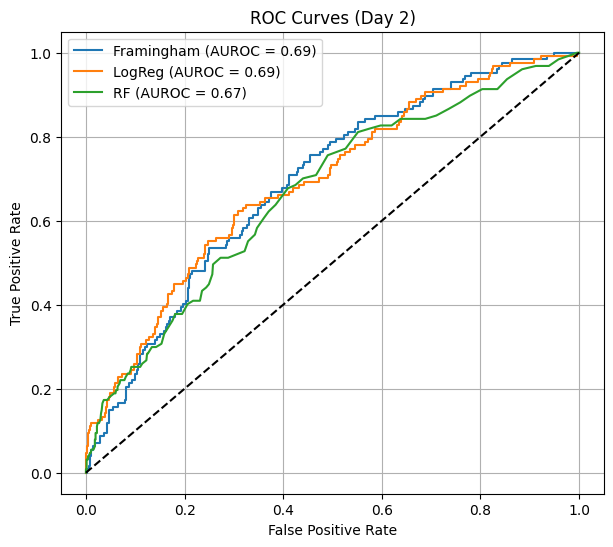

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(7, 6))


y_prob = framingham_baseline.predict_proba(Xb_test)[:,1]
fpr, tpr, _ = roc_curve(yb_test, y_prob)
roc_auc = roc_auc_score(yb_test, y_prob)
plt.plot(fpr, tpr, label=f"Framingham (AUROC = {roc_auc:.2f})")


y_prob = models["LogisticRegression"].predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
plt.plot(fpr, tpr, label=f"LogReg (AUROC = {roc_auc:.2f})")


y_prob = models["RandomForest"].predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
plt.plot(fpr, tpr, label=f"RF (AUROC = {roc_auc:.2f})")


plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Day 2)")
plt.legend()
plt.grid(True)
plt.savefig("roc_all.png", dpi=300)
plt.show()


In [12]:
plt.figure(figsize=(7, 6))

# For Framingham
y_prob = framingham_baseline.predict_proba(Xb_test)[:,1]
precision, recall, _ = precision_recall_curve(yb_test, y_prob)
ap = average_precision_score(yb_test, y_prob)
plt.plot(recall, precision, label=f"Framingham (AUPRC = {ap:.2f})")

# For Logistic Regression
y_prob = models["LogisticRegression"].predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
plt.plot(recall, precision, label=f"LogReg (AUPRC = {ap:.2f})")

# For Random Forest
y_prob = models["RandomForest"].predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
plt.plot(recall, precision, label=f"RF (AUPRC = {ap:.2f})")

# For Baseline prevalence
no_skill = y_test.mean()
plt.plot([0,1],[no_skill,no_skill],'k--', label="No skill")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Day 2)")
plt.legend()
plt.grid(True)
plt.savefig("pr_all.png", dpi=300)
plt.show()


NameError: name 'precision_recall_curve' is not defined

<Figure size 700x600 with 0 Axes>

In [13]:
# The Faislabad caridology hospital  dataset
pk_path = "/kaggle/input/pakistanidataset/FIC.Full CSV.csv"  
pk_df = pd.read_csv(pk_path)

# Compare columns
framingham_cols = set(df.columns)
pak_cols = set(pk_df.columns)

common_cols = framingham_cols.intersection(pak_cols)
unique_fram = framingham_cols - pak_cols
unique_pak = pak_cols - framingham_cols

print("Common features:", common_cols)
print("Framingham-only:", unique_fram)
print("Pakistan-only:", unique_pak)

with open("feature_mapping.md", "w") as f:
    f.write("### Feature Mapping (Framingham vs Pakistan)\n\n")
    f.write("**Common Features:**\n" + ", ".join(common_cols) + "\n\n")
    f.write("**Framingham-only:**\n" + ", ".join(unique_fram) + "\n\n")
    f.write("**Pakistan-only:**\n" + ", ".join(unique_pak) + "\n\n")


Common features: set()
Framingham-only: {'cigsPerDay', 'glucose', 'prevalentStroke', 'prevalentHyp', 'BMI', 'age', 'BPMeds', 'currentSmoker', 'male', 'education', 'pulse_pressure', 'heartRate', 'sysBP', 'TenYearCHD', 'diabetes', 'diaBP', 'totChol'}
Pakistan-only: {'Depression', 'S.Sodium', 'SK', 'Gender', 'Smoking', 'BGR', 'NEUTROPHIL', 'LYMPHO', 'Follow.Up', 'MONOCYTE', 'HTN', 'RBC', 'Mortality', 'ESR', 'Allergies', 'BP', 'ca', 'restecg', 'Hyperlipi', 'Age', 'CO', 'cp', 'PLATELET_COUNT', 'trestbps', 'Reaction', 'Diabetes', 'Marital status                       ', 'C.P.K', 'Age.Group', 'F.History', 'Family.History', 'S.Cr', 'chol', 'Thrombolysis', 'CK.MB', 'S.Potassium', 'slope', 'M.C.V', 'P.C.V', 'Others ', 'Sleep', 'Diagnosis', 'num', 'exang', 'M.C.H.C', 'Hemoglobin', 'EOSINO', 'fbs', 'oldpeak', 'thal', 'B.Urea', 'S.Chloride', 'Life.Style                                                                              ', 'SK.React', 'M.C.H', 'Hypersensitivity', 'WBC', 'Category', 'thalac

In [14]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.special import expit
import statsmodels.api as sm
from sklearn.calibration import calibration_curve
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.metrics import brier_score_loss
import os
os.makedirs("baseline", exist_ok=True)


def safe_logit(p, eps=1e-6):
    p = np.clip(p, eps, 1-eps)
    return np.log(p/(1-p))


In [15]:

import random

def fit_logit_on_logit(y, probs):
    """
    Fit logistic regression y ~ const + logit(p_hat).
    Returns (intercept, slope) from statsmodels Logit fit.
    """
    logit_p = safe_logit(probs)
    X = sm.add_constant(logit_p)
    model = sm.Logit(y, X)
    res = model.fit(disp=False)
    intercept = float(res.params[0])
    slope = float(res.params[1])
    return intercept, slope

def bootstrap_slope_intercept(y, probs, n_boot=500, seed=42):
    rng = np.random.RandomState(seed)
    ints = []
    slps = []
    n = len(y)
    for i in range(n_boot):
        idx = rng.choice(np.arange(n), size=n, replace=True)
        try:
            itc, slp = fit_logit_on_logit(y.iloc[idx].reset_index(drop=True), probs[idx])
        except Exception as e:
            # fallback: skip this resample
            continue
        ints.append(itc)
        slps.append(slp)
    return {
        "intercept_mean": np.mean(ints),
        "intercept_ci": (np.percentile(ints, 2.5), np.percentile(ints, 97.5)),
        "slope_mean": np.mean(slps),
        "slope_ci": (np.percentile(slps, 2.5), np.percentile(slps, 97.5))
    }


In [16]:

try:
    X_test_scaled
except NameError:
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    scaler.fit(X_train)  # use your training set scaling
    X_test_scaled = scaler.transform(X_test)


calib_records = []

# mapping of models -> (model_obj, X_eval, y_eval, name)
model_eval_map = {
    "Framingham": (framingham_baseline, Xb_test, yb_test),
    "LogisticRegression": (models["LogisticRegression"], X_test_scaled, y_test),
    "RandomForest": (models["RandomForest"], X_test, y_test)
}

for name, (mdl, X_eval, y_eval) in model_eval_map.items():
   
    probs = mdl.predict_proba(X_eval)[:,1]
   
    intercept, slope = fit_logit_on_logit(y_eval.reset_index(drop=True), probs)
 
    boot = bootstrap_slope_intercept(y_eval.reset_index(drop=True), probs, n_boot=500, seed=42)
    # brier
    brier = brier_score_loss(y_eval, probs)
    record = {
        "Model": name,
        "Intercept": intercept,
        "Intercept_low": boot["intercept_ci"][0],
        "Intercept_high": boot["intercept_ci"][1],
        "Slope": slope,
        "Slope_low": boot["slope_ci"][0],
        "Slope_high": boot["slope_ci"][1],
        "Brier": brier
    }
    calib_records.append(record)

calib_df = pd.DataFrame(calib_records)
calib_df.to_csv("baseline/calibration_table.csv", index=False)
calib_df


/tmp/ipykernel_38/2539431729.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = float(res.params[0])
/tmp/ipykernel_38/2539431729.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = float(res.params[1])
/tmp/ipykernel_38/2539431729.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = float(res.params[0])
/tmp/ipykernel_38/2539431729.py:14: FutureWarning: Series.__getitem__ treating keys as position

,Model,Intercept,Intercept_low,Intercept_high,Slope,Slope_low,Slope_high,Brier
0,Framingham,-0.315663,-0.704786,0.066134,0.790112,0.565956,1.009255,0.122012
1,LogisticRegression,-0.360006,-0.754022,-0.032465,0.766137,0.546284,0.970198,0.118596
2,RandomForest,-0.722239,-1.100481,-0.377034,0.549735,0.334721,0.763789,0.123657


Best model by AUROC (day2): LogisticRegression
Using LogisticRegression for intercept-only recalibration demo


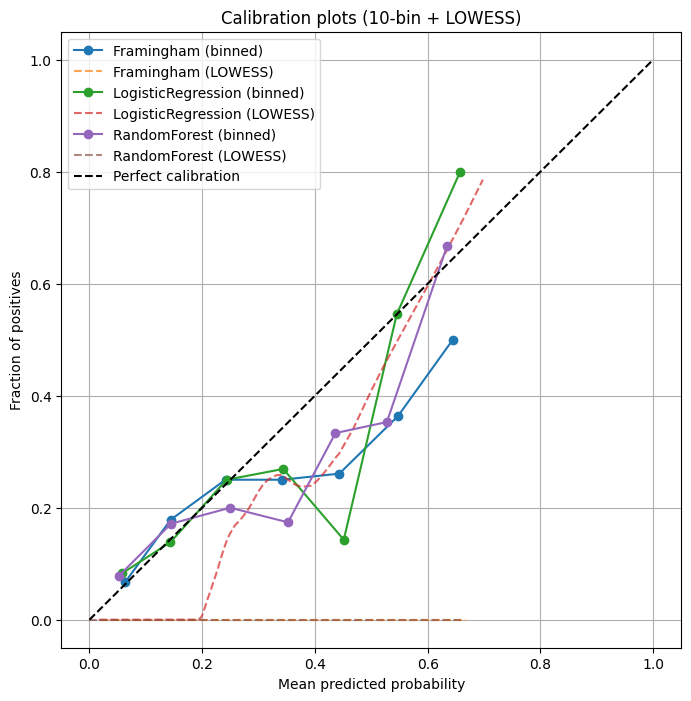

/tmp/ipykernel_38/2086370443.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_only = float(res_offset.params[0])


Intercept-only fit intercept: -0.001283858788186959


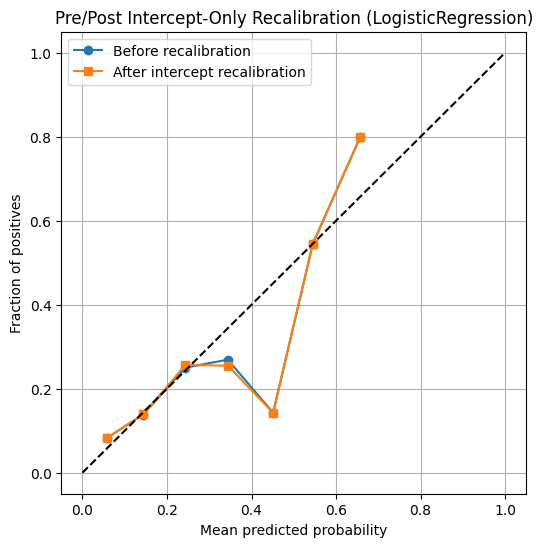

In [17]:
# Cell D
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

# This Cell is to choose the best model by AUROC from my metrics
# If you have metrics_df from day2:
try:
    best_model_name = metrics_df.sort_values("AUROC", ascending=False).iloc[0]["Model"]
    print("Best model by AUROC (day2):", best_model_name)
except:
    best_model_name = "LogisticRegression"
print("Using", best_model_name, "for intercept-only recalibration demo")

#  plots for each model
plt.figure(figsize=(8, 8))
for name, (mdl, X_eval, y_eval) in model_eval_map.items():
    probs = mdl.predict_proba(X_eval)[:,1]
    frac_pos, mean_pred = calibration_curve(y_eval, probs, n_bins=10, strategy='uniform')
    plt.plot(mean_pred, frac_pos, marker='o', linestyle='-', label=f"{name} (binned)")
   
    lw = lowess(y_eval, probs, frac=0.25)
    plt.plot(lw[:,0], lw[:,1], linestyle='--', alpha=0.7, label=f"{name} (LOWESS)")

plt.plot([0,1],[0,1],'k--', label='Perfect calibration')
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration plots (10-bin + LOWESS)")
plt.legend()
plt.grid(True)
plt.savefig("baseline/calibration_combined.png", dpi=300)
plt.show()


best_mdl, best_X, best_y = model_eval_map[best_model_name]
probs = best_mdl.predict_proba(best_X)[:,1]
logit_p = safe_logit(probs)

exog = sm.add_constant(np.ones(len(best_y)))  # to just intercept the column
glm_offset = sm.GLM(best_y.reset_index(drop=True), exog, family=sm.families.Binomial(), offset=logit_p)
res_offset = glm_offset.fit()
intercept_only = float(res_offset.params[0])
print("Intercept-only fit intercept:", intercept_only)

recal_logit = logit_p + intercept_only
recal_probs = expit(recal_logit)


frac_pre, mean_pre = calibration_curve(best_y, probs, n_bins=10)
frac_post, mean_post = calibration_curve(best_y, recal_probs, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(mean_pre, frac_pre, 'o-', label='Before recalibration')
plt.plot(mean_post, frac_post, 's-', label='After intercept recalibration')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title(f"Pre/Post Intercept-Only Recalibration ({best_model_name})")
plt.legend()
plt.grid(True)
plt.savefig(f"baseline/{best_model_name}_prepost_recalibration.png", dpi=300)
plt.show()


pd.DataFrame({"y_true": best_y.reset_index(drop=True), "prob_before": probs, "prob_after": recal_probs}).to_csv(
    f"baseline/{best_model_name}_recalibration_probs.csv", index=False
)


/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


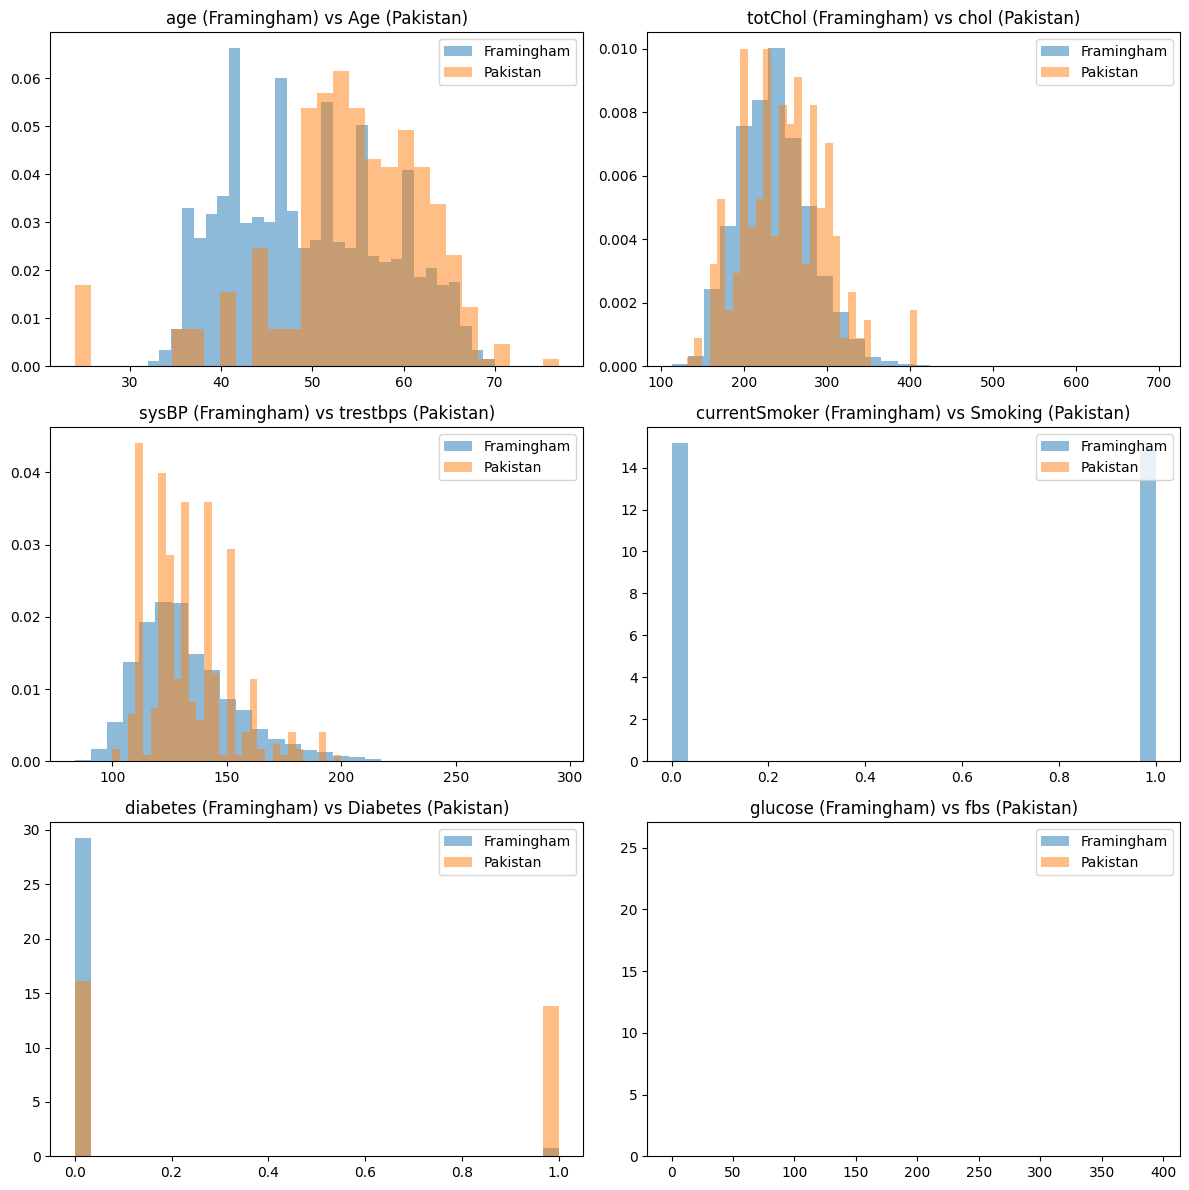

Reduced features used (Framingham columns): ['age', 'totChol', 'sysBP', 'currentSmoker', 'diabetes', 'glucose']
Saved reduced models and metrics.


,Model,AUROC,AUPRC
0,RF_reduced,0.670909,0.257062
1,LR_reduced,0.690007,0.290245


In [18]:
# Cell E
# manual mapping dictionary -
mapping = {
    "age": ["age", "Age"],
    "totChol": ["totchol","chol","cholestoral","cholesterol"],
    "sysBP": ["sysbp","trestbps","bp","bp_systolic","restbps"],
    "currentSmoker": ["currentsmoker","smoking","smoker","Smoking"],
    "diabetes": ["diabetes","Diabetes","Diabetes "],
    "glucose": ["glucose","fbs","bgr","BGR"]
}


def find_pk_col(candidates, pk_cols_lower_map):
    for c in candidates:
        if c in pk_cols_lower_map:
            return pk_cols_lower_map[c]
    return None


pk_cols_lower_map = {col.lower().strip(): col for col in pk_df.columns}

pairs = {}
for fr_col, pk_candidates in mapping.items():
    if fr_col in df.columns:
        pk_match = find_pk_col(pk_candidates, pk_cols_lower_map)
        if pk_match:
            pairs[fr_col] = pk_match

pairs
# Plot numeric distributions side-by-side
num_plots = len(pairs)
if num_plots==0:
    print("No pairs found automatically. You must decide manual mapping.")
else:
    ncols = 2
    nrows = int(np.ceil(num_plots / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(12, 4*nrows))
    axs = axs.flatten()
    i = 0
    for fr_col, pk_col in pairs.items():
        col_fr = df[fr_col].dropna()
        col_pk = pk_df[pk_col].dropna()
  
        try:
            col_fr = pd.to_numeric(col_fr, errors='coerce').dropna()
            col_pk = pd.to_numeric(col_pk, errors='coerce').dropna()
            axs[i].hist(col_fr, bins=30, alpha=0.5, density=True, label='Framingham')
            axs[i].hist(col_pk, bins=30, alpha=0.5, density=True, label='Pakistan')
            axs[i].set_title(f"{fr_col} (Framingham) vs {pk_col} (Pakistan)")
            axs[i].legend()
        except Exception as e:
            axs[i].text(0.1, 0.5, f"Cannot plot {fr_col} vs {pk_col}")
        i += 1
    for j in range(i, len(axs)):
        fig.delaxes(axs[j])
    plt.tight_layout()
    plt.savefig("baseline/distribution_comparison.png", dpi=300)
    plt.show()

reduced_features = list(pairs.keys())
print("Reduced features used (Framingham columns):", reduced_features)

X_red = df[reduced_features].copy()
y_full = df["TenYearCHD"]


from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
imp = SimpleImputer(strategy="mean")
sc = StandardScaler()

X_red_imp = imp.fit_transform(X_red)
X_red_scaled = sc.fit_transform(X_red_imp)

from sklearn.model_selection import train_test_split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_red_scaled, y_full, test_size=0.2, stratify=y_full, random_state=SEED)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

rf_red = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
lr_red = LogisticRegression(max_iter=1000, random_state=SEED)

rf_red.fit(Xr_train, yr_train)
lr_red.fit(Xr_train, yr_train)


from sklearn.metrics import roc_auc_score, average_precision_score
rf_probs = rf_red.predict_proba(Xr_test)[:,1]
lr_probs = lr_red.predict_proba(Xr_test)[:,1]
reduced_metrics = pd.DataFrame([
    {"Model":"RF_reduced", "AUROC":roc_auc_score(yr_test, rf_probs), "AUPRC":average_precision_score(yr_test, rf_probs)},
    {"Model":"LR_reduced", "AUROC":roc_auc_score(yr_test, lr_probs), "AUPRC":average_precision_score(yr_test, lr_probs)}
])
reduced_metrics.to_csv("baseline/reduced_feature_metrics.csv", index=False)
joblib.dump(rf_red, "baseline/reduced_RF.pkl")
joblib.dump(lr_red, "baseline/reduced_LR.pkl")
print("Saved reduced models and metrics.")
reduced_metrics


In [19]:
# Cell F
# Using the pairs dictionary keys as Framingham columns present and mapped to pk columns
reduced_features = list(pairs.keys())
print("Reduced features used (Framingham columns):", reduced_features)

X_red = df[reduced_features].copy()
y_full = df["TenYearCHD"]

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
imp = SimpleImputer(strategy="mean")
sc = StandardScaler()

X_red_imp = imp.fit_transform(X_red)
X_red_scaled = sc.fit_transform(X_red_imp)

from sklearn.model_selection import train_test_split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_red_scaled, y_full, test_size=0.2, stratify=y_full, random_state=SEED)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

rf_red = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
lr_red = LogisticRegression(max_iter=1000, random_state=SEED)

rf_red.fit(Xr_train, yr_train)
lr_red.fit(Xr_train, yr_train)


from sklearn.metrics import roc_auc_score, average_precision_score
rf_probs = rf_red.predict_proba(Xr_test)[:,1]
lr_probs = lr_red.predict_proba(Xr_test)[:,1]
reduced_metrics = pd.DataFrame([
    {"Model":"RF_reduced", "AUROC":roc_auc_score(yr_test, rf_probs), "AUPRC":average_precision_score(yr_test, rf_probs)},
    {"Model":"LR_reduced", "AUROC":roc_auc_score(yr_test, lr_probs), "AUPRC":average_precision_score(yr_test, lr_probs)}
])
reduced_metrics.to_csv("baseline/reduced_feature_metrics.csv", index=False)
joblib.dump(rf_red, "baseline/reduced_RF.pkl")
joblib.dump(lr_red, "baseline/reduced_LR.pkl")
print("Saved reduced models and metrics.")
reduced_metrics


Reduced features used (Framingham columns): ['age', 'totChol', 'sysBP', 'currentSmoker', 'diabetes', 'glucose']
Saved reduced models and metrics.


,Model,AUROC,AUPRC
0,RF_reduced,0.670909,0.257062
1,LR_reduced,0.690007,0.290245


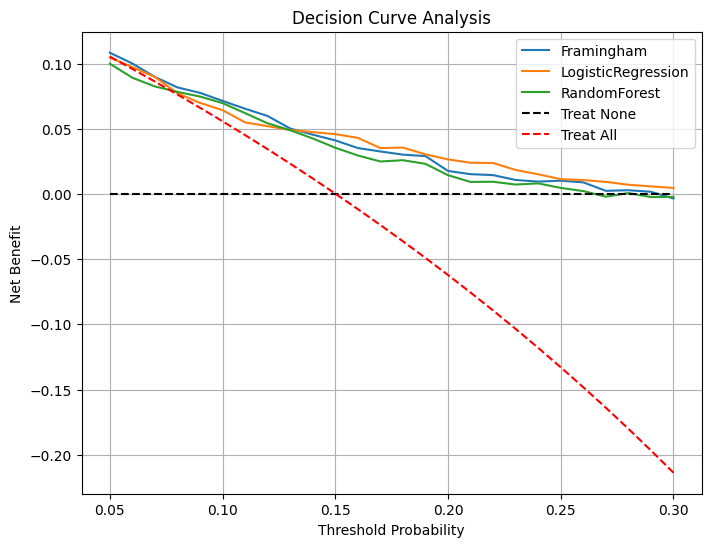

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def net_benefit(y_true, y_prob, thresholds):
    N = len(y_true)
    results = []
    for pt in thresholds:
        preds = (y_prob >= pt).astype(int)
        TP = np.sum((preds == 1) & (y_true == 1))
        FP = np.sum((preds == 1) & (y_true == 0))
        nb = (TP / N) - (FP / N) * (pt / (1 - pt))
        results.append(nb)
    return results


thresholds = np.arange(0.05, 0.31, 0.01)


dca_results = {}
for name, (mdl, X_eval, y_eval) in model_eval_map.items():
    y_prob = mdl.predict_proba(X_eval)[:,1]
    dca_results[name] = net_benefit(y_eval, y_prob, thresholds)


treat_none = [0] * len(thresholds)
event_rate = np.mean(y_test)
treat_all = [event_rate - (1-event_rate) * (pt/(1-pt)) for pt in thresholds]


plt.figure(figsize=(8,6))
for name, nb in dca_results.items():
    plt.plot(thresholds, nb, label=name)
plt.plot(thresholds, treat_none, 'k--', label="Treat None")
plt.plot(thresholds, treat_all, 'r--', label="Treat All")
plt.xlabel("Threshold Probability")
plt.ylabel("Net Benefit")
plt.title("Decision Curve Analysis")
plt.legend()
plt.grid(True)
plt.savefig("decision_curve.png", dpi=300)
plt.show()


In [22]:

X_test_scaled_df = pd.DataFrame(X_test_scaled, index=y_test.index, columns=X.columns)

lr_model = models["LogisticRegression"]


subgroups = {
    "Age<50": (X_test_scaled_df[df.loc[y_test.index, "age"] < 50], y_test[df.loc[y_test.index, "age"] < 50]),
    "Age>=50": (X_test_scaled_df[df.loc[y_test.index, "age"] >= 50], y_test[df.loc[y_test.index, "age"] >= 50]),
    "Male": (X_test_scaled_df[df.loc[y_test.index, "male"] == 1], y_test[df.loc[y_test.index, "male"] == 1]),
    "Female": (X_test_scaled_df[df.loc[y_test.index, "male"] == 0], y_test[df.loc[y_test.index, "male"] == 0]),
    "Diabetes": (X_test_scaled_df[df.loc[y_test.index, "diabetes"] == 1], y_test[df.loc[y_test.index, "diabetes"] == 1]),
    "No Diabetes": (X_test_scaled_df[df.loc[y_test.index, "diabetes"] == 0], y_test[df.loc[y_test.index, "diabetes"] == 0]),
}


def evaluate_subgroup(model, Xg, yg):
    if len(yg) < 10: 
        return None
    y_prob = model.predict_proba(Xg.values)[:,1] 
    return {
        "AUROC": roc_auc_score(yg, y_prob),
        "AUPRC": average_precision_score(yg, y_prob),
        "Brier": brier_score_loss(yg, y_prob)
    }

# Evaluate the subgroups
subgroup_results = {}
for g, (Xg, yg) in subgroups.items():
    res = evaluate_subgroup(lr_model, Xg, yg)
    if res:
        subgroup_results[g] = res

pd.DataFrame(subgroup_results).T.to_csv("subgroup_results.csv")


In [23]:

df_engineered = df.copy()

# New features
df_engineered["pulse_pressure"] = df_engineered["sysbp"] - df_engineered["diabp"]
df_engineered["chol_ratio"] = df_engineered["totchol"] / (df_engineered["hdl"] + 1e-6)  # avoid divide by zero

for col in ["totchol", "hdl", "glucose"]:
    df_engineered[f"{col}_missing"] = df_engineered[col].isna().astype(int)

df_engineered = df_engineered.fillna(df_engineered.median())

print(df_engineered.head())


KeyError: 'sysbp'

In [25]:

df_engineered = df.copy()


if "pulse_pressure" not in df_engineered.columns and {"sysBP", "diaBP"}.issubset(df_engineered.columns):
    df_engineered["pulse_pressure"] = df_engineered["sysBP"] - df_engineered["diaBP"]


if {"totChol", "HDL"}.issubset(df_engineered.columns):
    df_engineered["chol_ratio"] = df_engineered["totChol"] / (df_engineered["HDL"] + 1e-6)

print("New columns added (if available):", 
      [c for c in ["pulse_pressure", "chol_ratio"] if c in df_engineered.columns])



New columns added (if available): ['pulse_pressure']


In [26]:

OUTCOME_COL = "TenYearCHD"   


X = df_engineered.drop(columns=[OUTCOME_COL])
y = df_engineered[OUTCOME_COL]


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [27]:
print(df_engineered.columns.tolist())


['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD', 'pulse_pressure']


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

# Logistic Regression
lr_engineered = LogisticRegression(max_iter=1000, solver="liblinear")
lr_engineered.fit(X_train_scaled, y_train)

# Random Forest
rf_engineered = RandomForestClassifier(n_estimators=500, random_state=42)
rf_engineered.fit(X_train, y_train)  # RF doesn’t need scaling


RandomForestClassifier(n_estimators=500, random_state=42)

In [29]:
def evaluate_model(model, X_test, y_test, scaled=True):
    if scaled:
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.predict_proba(X_test)[:, 1]
    return {
        "AUROC": roc_auc_score(y_test, y_prob),
        "AUPRC": average_precision_score(y_test, y_prob),
        "Brier": brier_score_loss(y_test, y_prob)
    }

results_day6 = {
    "LogisticRegression_engineered": evaluate_model(lr_engineered, X_test_scaled, y_test, scaled=True),
    "RandomForest_engineered": evaluate_model(rf_engineered, X_test, y_test, scaled=False)
}

import pandas as pd
results_day6_df = pd.DataFrame(results_day6).T
print(results_day6_df)

# Save results
results_day6_df.to_csv("day6_feature_engineering_results.csv")


                                  AUROC     AUPRC     Brier
LogisticRegression_engineered  0.697405  0.320654  0.118647
RandomForest_engineered        0.669557  0.278521  0.122684


In [30]:

!pip install shap

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Logistic Regression
lr_model = models["LogisticRegression"]


X_test_scaled_df = pd.DataFrame(X_test_scaled, index=y_test.index, columns=X.columns)


explainer = shap.LinearExplainer(lr_model, X_train_scaled, feature_names=X.columns)
shap_values = explainer.shap_values(X_test_scaled_df)


plt.figure()
shap.summary_plot(shap_values, X_test_scaled_df, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300)
plt.close()


key_features = ["age", "sysBP", "pulse_pressure", "chol_ratio"]
for feat in key_features:
    if feat in X_test_scaled_df.columns:
        plt.figure()
        shap.dependence_plot(feat, shap_values, X_test_scaled_df, show=False)
        plt.tight_layout()
        plt.savefig(f"shap_dependence_{feat}.png", dpi=300)
        plt.close()

print("✅ SHAP summary + dependence plots saved.")


The figure layout has changed to tight


✅ SHAP summary + dependence plots saved.


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [34]:

y_prob = lr_model.predict_proba(X_test_scaled_df)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

results_df = pd.DataFrame({
    "y_true": y_test,
    "y_prob": y_prob,
    "y_pred": y_pred
}, index=y_test.index)

# Case A: True Positive (high risk, correctly classified)
caseA = results_df[(results_df.y_true == 1) & (results_df.y_pred == 1)].sort_values("y_prob", ascending=False).iloc[0]

# Case B: False Negative (CHD but predicted low)
caseB = results_df[(results_df.y_true == 1) & (results_df.y_pred == 0)].sort_values("y_prob", ascending=True).iloc[0]

# Extract feature values
def extract_case_features(idx):
    feats = X_test_scaled_df.loc[idx, ["age", "sysBP", "glucose"]] if "glucose" in X_test_scaled_df.columns else X_test_scaled_df.loc[idx, ["age", "sysBP"]]
    return feats.to_dict()

caseA_feats = extract_case_features(caseA.name)
caseB_feats = extract_case_features(caseB.name)

print("Case A (True Positive):", caseA_feats, "Pred prob:", caseA.y_prob)
print("Case B (False Negative):", caseB_feats, "Pred prob:", caseB.y_prob)


Case A (True Positive): {'age': 1.0989952733230983, 'sysBP': 5.050846971896094, 'glucose': 1.6598533873630839} Pred prob: 0.6829176790847898
Case B (False Negative): {'age': -1.595917090343771, 'sysBP': -1.5678116899311436, 'glucose': -0.3760922672800931} Pred prob: 0.01829859000841333


X has feature names, but LogisticRegression was fitted without feature names


In [36]:

def counterfactual_risk_change(idx, feature="sysBP", delta=-10):
    x = X_test_scaled_df.loc[idx].copy()
    if feature not in X_test_scaled_df.columns:
        return None
    baseline_prob = lr_model.predict_proba([x])[0,1]

 
    x[feature] = x[feature] + delta
    new_prob = lr_model.predict_proba([x])[0,1]
    return baseline_prob, new_prob


baseline, new = counterfactual_risk_change(caseA.name, "sysBP", -10)
if baseline and new:
    print(f"Actionable Insight: Lowering SBP by 10 mmHg shifts predicted risk from {baseline:.3f} to {new:.3f} (~{(baseline-new)*100:.1f}% reduction).")


Actionable Insight: Lowering SBP by 10 mmHg shifts predicted risk from 0.683 to 0.314 (~36.9% reduction).


In [37]:

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import random
import math

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)


In [38]:

def auroc(y_true, y_pred_prob):
    return float(roc_auc_score(y_true, y_pred_prob))

def auprc(y_true, y_pred_prob):
    return float(average_precision_score(y_true, y_pred_prob))

def brier(y_true, y_pred_prob):
    return float(brier_score_loss(y_true, y_pred_prob))

def calibration_intercept_slope(y_true, y_pred_prob, eps=1e-8):
    # logistic recalibration: fit logistic regression on logit(p) or on p with transformation
    p = np.clip(y_pred_prob, eps, 1 - eps)
    logit = np.log(p / (1 - p)).reshape(-1, 1)
    lr = LogisticRegression(penalty='none', solver='lbfgs', max_iter=200)
    lr.fit(logit, y_true)
    slope = float(lr.coef_[0][0])
    intercept = float(lr.intercept_[0])
    return intercept, slope


In [42]:

def bootstrap_ci(y_true, y_pred_prob, metric_fn, n_boot=500, seed=RANDOM_SEED, strata=True, n_jobs=1):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    idx = np.arange(n)
    
    classes = np.unique(y_true)
    boots = []
    for i in range(n_boot):
        if strata:
            sample_idx = np.concatenate([
                rng.choice(idx[y_true == c], size=(y_true == c).sum(), replace=True)
                for c in classes
            ])
        else:
            sample_idx = rng.choice(idx, size=n, replace=True)
        m = metric_fn(y_true[sample_idx], y_pred_prob[sample_idx])
        boots.append(m)
    boots = np.array(boots)
    lower = np.percentile(boots, 2.5)
    upper = np.percentile(boots, 97.5)
    mean = boots.mean()
    std = boots.std(ddof=1)
    return {'mean': float(mean), 'std': float(std), '2.5%': float(lower), '97.5%': float(upper), 'boots': boots}


In [44]:

def bootstrap_calibration(y_true, y_pred_prob, n_boot=500, seed=RANDOM_SEED, strata=True):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    idx = np.arange(n)
    classes = np.unique(y_true)
    intercepts = []
    slopes = []
    for i in range(n_boot):
        if strata:
            sample_idx = np.concatenate([
                rng.choice(idx[y_true == c], size=(y_true == c).sum(), replace=True)
                for c in classes
            ])
        else:
            sample_idx = rng.choice(idx, size=n, replace=True)
        inter, sl = calibration_intercept_slope(y_true[sample_idx], y_pred_prob[sample_idx])
        intercepts.append(inter)
        slopes.append(sl)
    inter = np.array(intercepts)
    sl = np.array(slopes)
    return {
        'intercept_mean': float(inter.mean()), 'intercept_std': float(inter.std(ddof=1)),
        'intercept_2.5%': float(np.percentile(inter, 2.5)), 'intercept_97.5%': float(np.percentile(inter, 97.5)),
        'slope_mean': float(sl.mean()), 'slope_std': float(sl.std(ddof=1)),
        'slope_2.5%': float(np.percentile(sl, 2.5)), 'slope_97.5%': float(np.percentile(sl, 97.5)),
        'intercept_boots': inter, 'slope_boots': sl
    }


In [45]:

def paired_bootstrap_test(y_true, y_predA, y_predB, metric_fn, n_boot=500, seed=RANDOM_SEED, strata=True):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    idx = np.arange(n)
    classes = np.unique(y_true)
    diffs = []
    for i in range(n_boot):
        if strata:
            sample_idx = np.concatenate([
                rng.choice(idx[y_true == c], size=(y_true == c).sum(), replace=True)
                for c in classes
            ])
        else:
            sample_idx = rng.choice(idx, size=n, replace=True)
        mA = metric_fn(y_true[sample_idx], y_predA[sample_idx])
        mB = metric_fn(y_true[sample_idx], y_predB[sample_idx])
        diffs.append(mA - mB)
    diffs = np.array(diffs)
    # two-sided p-value: proportion of diffs <= 0 or >=0 depending direction
    # use two-sided
    p_two_sided = 2.0 * min((diffs <= 0).mean(), (diffs >= 0).mean())
    return {'diff_mean': float(diffs.mean()), 'diff_std': float(diffs.std(ddof=1)),
            '2.5%': float(np.percentile(diffs, 2.5)), '97.5%': float(np.percentile(diffs, 97.5)),
            'p_two_sided': float(p_two_sided), 'boots': diffs}


In [47]:

def compute_metrics_with_ci(y_true, y_pred_prob, n_boot=500):
    r = {}
    r['AUROC'] = bootstrap_ci(y_true, y_pred_prob, auroc, n_boot=n_boot)
    r['AUPRC'] = bootstrap_ci(y_true, y_pred_prob, auprc, n_boot=n_boot)
    r['Brier'] = bootstrap_ci(y_true, y_pred_prob, brier, n_boot=n_boot)
    cal = bootstrap_calibration(y_true, y_pred_prob, n_boot=n_boot)
    r['Calibration_intercept'] = {
        'mean': cal['intercept_mean'], 'std': cal['intercept_std'],
        '2.5%': cal['intercept_2.5%'], '97.5%': cal['intercept_97.5%']
    }
    r['Calibration_slope'] = {
        'mean': cal['slope_mean'], 'std': cal['slope_std'],
        '2.5%': cal['slope_2.5%'], '97.5%': cal['slope_97.5%']
    }
    return r


In [53]:

y_test_np = y_test.reset_index(drop=True).to_numpy()
X_test_np = X_test.reset_index(drop=True).to_numpy()

n_boot = 500
results = {}

for name, model in models.items():

    if hasattr(model, "predict_proba"):
        p = model.predict_proba(X_test_np)[:, 1]
    else:
        scores = model.decision_function(X_test_np)
        p = 1 / (1 + np.exp(-scores))


    p_np = np.array(p)

    # Compute metrics safely using numpy arrays
    res = compute_metrics_with_ci(y_test_np, p_np, n_boot=n_boot)
    results[name] = res

#results 
rows = []
for name, stats in results.items():
    rows.append({
        'model': name,
        'AUROC (mean [95%CI])': f"{stats['AUROC']['mean']:.3f} [{stats['AUROC']['2.5%']:.3f}-{stats['AUROC']['97.5%']:.3f}]",
        'AUPRC (mean [95%CI])': f"{stats['AUPRC']['mean']:.3f} [{stats['AUPRC']['2.5%']:.3f}-{stats['AUPRC']['97.5%']:.3f}]",
        'Brier (mean [95%CI])': f"{stats['Brier']['mean']:.3f} [{stats['Brier']['2.5%']:.3f}-{stats['Brier']['97.5%']:.3f}]",
        'Cal Intercept (mean [95%CI])': f"{stats['Calibration_intercept']['mean']:.3f} [{stats['Calibration_intercept']['2.5%']:.3f}-{stats['Calibration_intercept']['97.5%']:.3f}]",
        'Cal Slope (mean [95%CI])': f"{stats['Calibration_slope']['mean']:.3f} [{stats['Calibration_slope']['2.5%']:.3f}-{stats['Calibration_slope']['97.5%']:.3f}]"
    })

df_results = pd.DataFrame(rows)
df_results


`penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
`penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
`penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
`penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
`penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
`penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
`penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
`penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
`penalty='none'`has been deprecated in 1.2 and w

,model,AUROC (mean [95%CI]),AUPRC (mean [95%CI]),Brier (mean [95%CI]),Cal Intercept (mean [95%CI]),Cal Slope (mean [95%CI])
0,LogisticRegression,0.500 [0.500-0.500],0.150 [0.150-0.150],0.850 [0.850-0.850],-0.005 [-0.005--0.005],-0.094 [-0.094--0.094]
1,RandomForest,0.597 [0.549-0.643],0.195 [0.170-0.222],0.353 [0.350-0.355],-2.785 [-3.279--2.279],1.938 [1.016-2.820]


In [55]:
models.keys()

dict_keys(['LogisticRegression', 'RandomForest'])

In [56]:
# Cell 8 - paired comparisons
n_boot = 500
nameA, nameB = 'LogisticRegression', 'RandomForest'  
pA = models[nameA].predict_proba(X_test)[:, 1]
pB = models[nameB].predict_proba(X_test)[:, 1]

res_auroc = paired_bootstrap_test(y_test, pA, pB, auroc, n_boot=n_boot)
res_auprc = paired_bootstrap_test(y_test, pA, pB, auprc, n_boot=n_boot)
res_brier = paired_bootstrap_test(y_test, pA, pB, brier, n_boot=n_boot)

print("LR vs RF AUROC paired bootstrap:", res_auroc['diff_mean'], "p=", res_auroc['p_two_sided'])
print("LR vs RF AUPRC paired bootstrap:", res_auprc['diff_mean'], "p=", res_auprc['p_two_sided'])
print("LR vs RF Brier paired bootstrap:", res_brier['diff_mean'], "p=", res_brier['p_two_sided'])


X has feature names, but LogisticRegression was fitted without feature names
X has feature names, but RandomForestClassifier was fitted without feature names


KeyError: '[141, 102, 908, 947, 1124, 333, 303, 882, 1007, 604, 1147, 223, 1127, 811, 662, 976, 764, 25, 987, 196, 714, 377, 287, 915, 665, 108, 599, 1208, 1204, 666, 827, 859, 1171, 325, 540, 1198, 353, 400, 1036, 1266, 253, 219, 445, 581, 1253, 16, 77, 614, 458, 490, 346, 444, 274, 1200, 157, 234, 919, 1261, 593, 946, 854, 1130, 728, 760, 1025, 459, 242, 1222, 1051, 1015, 1203, 113, 573, 883, 638, 1247, 680, 656, 1193, 763, 937, 750, 834, 379, 1120, 259, 1005, 294, 237, 351, 336, 1153, 166, 723, 218, 548, 780, 1123, 472, 577, 1091, 758, 559, 175, 408, 739, 1038, 1057, 1248, 1196, 10, 243, 473, 176, 691, 122, 603, 178, 1035, 1125, 187, 942, 812, 556, 1230, 884, 272, 516, 939, 340, 1129, 1202, 778, 646, 18, 183, 1259, 586, 361, 211, 720, 1168, 224, 1152, 19, 741, 1004, 1131, 925, 293, 1250, 896, 1082, 1063, 809, 382, 469, 772, 1141, 557, 978, 855, 61, 677, 174, 375, 364, 1179, 319, 1180, 1034, 1167, 56, 966, 324, 753, 139, 975, 874, 751, 606, 943, 659, 576, 828, 684, 179, 1172, 821, 11

In [58]:

nameA = 'LogisticRegression'
nameB = 'RandomForest'
pA_np = models[nameA].predict_proba(X_test_np)[:, 1]
pB_np = models[nameB].predict_proba(X_test_np)[:, 1]
pA_np = np.array(pA_np)
pB_np = np.array(pB_np)

# run paired bootstrap significance tests
res_auroc = paired_bootstrap_test(y_test_np, pA_np, pB_np, auroc, n_boot=n_boot)
res_auprc = paired_bootstrap_test(y_test_np, pA_np, pB_np, auprc, n_boot=n_boot)
res_brier = paired_bootstrap_test(y_test_np, pA_np, pB_np, brier, n_boot=n_boot)

print("LR vs RF AUROC p-value:", res_auroc)
print("LR vs RF AUPRC p-value:", res_auprc)
print("LR vs RF Brier p-value:", res_brier)


LR vs RF AUROC p-value: {'diff_mean': -0.09722387724185114, 'diff_std': 0.02343326658758688, '2.5%': -0.14315539021648824, '97.5%': -0.04940593998924892, 'p_two_sided': 0.0, 'boots': array([-0.13323804, -0.0874774 , -0.12373552, -0.098121  , -0.07452475,
       -0.09511557, -0.08344084, -0.15550506, -0.03564482, -0.11116161,
       -0.0841079 , -0.10177393, -0.07645262, -0.0697796 , -0.09911303,
       -0.16804965, -0.0719005 , -0.07686556, -0.09103504, -0.09343449,
       -0.08849387, -0.09142354, -0.13692763, -0.10151249, -0.11259346,
       -0.04025803, -0.13848165, -0.07432195, -0.09448517, -0.0978791 ,
       -0.07037091, -0.10789962, -0.07492059, -0.1551361 , -0.13213605,
       -0.113715  , -0.10726189, -0.08670527, -0.12212041, -0.12118213,
       -0.09009676, -0.11450423, -0.10091873, -0.12375263, -0.0876069 ,
       -0.11417681, -0.0946953 , -0.12746176, -0.07083761, -0.10574207,
       -0.11424767, -0.07789425, -0.11118604, -0.14605874, -0.06994576,
       -0.12256023, -0.09